# Analysis of JV Curves: Experimental Data vs SCAPS Simulations

## Overview
This notebook automates the analysis and comparison of J-V (current density-voltage) curves from laboratory measurements with those simulated using SCAPS (Solar Cell Capacitance Simulator). The goal is to validate the photovoltaic device model by comparing experimental performance with multiple simulation scenarios, identifying which simulations best match the measured behavior through parameter-based and shape-based matching algorithms.

## Section 1: Configuration and Target Parameters

In this section, we define the target performance metrics and experimental calibration parameters. These values represent the expected or desired photovoltaic device performance and are used to:
- **Normalize** the device's electrical characteristics
- **Convert** experimental current to current density
- **Set reference points** for comparing simulations against experiments

In [31]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go
from scipy.interpolate import interp1d
from sklearn.metrics import mean_squared_error
import warnings
import os
warnings.filterwarnings('ignore')

# Create plots directory if it doesn't exist
plots_dir = 'Plots'
if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
    print(f"✅ Created '{plots_dir}' directory for saving plots")

# -------------------------------------------------------------
# 1. DEFINE YOUR TARGET VALUES HERE
# -------------------------------------------------------------
TARGET_VOC = 0.38   # Volts (V)
TARGET_JSC = 20.31    # mA/cm2
TARGET_FF  = 49.56    # %
TARGET_ETA = 4.57     # %

# -------------------------------------------------------------
# 2. EXPERIMENTAL CALIBRATION
# -------------------------------------------------------------
# Define your cell's active area in cm² to convert I to J (mA/cm²)
ACTIVE_AREA_CM2 = 0.1 #this will be calculated after, is just a placeholder for now

# SCAPS typically outputs negative photocurrent.
# If your experimental measurement yielded positive current values, 
# the code automatically inverts them to make both curves comparable.
INVERT_EXP_CURRENT = True

## Theoretical Foundation: The Single-Diode Model

### Overview
The behavior of photovoltaic devices under illumination is commonly modeled using the **single-diode equivalent circuit**, which provides a physical interpretation of J-V curves. This model connects microscopic device physics to macroscopic electrical measurements.

### Mathematical Framework

The current-voltage relationship in solar cells is described by the **Shockley ideal diode equation**:

$$J = J_L - J_0 \left[\exp\left(\frac{qV}{nk_BT}\right) - 1\right] - \frac{V}{R_{sh}}$$

where:
- $J$ = current density (mA/cm²)
- $J_L$ = light-generated current density (photocurrent)
- $J_0$ = dark saturation current density (reverse saturation)
- $q$ = elementary charge (1.602 × 10⁻¹⁹ C)
- $V$ = applied voltage (V)
- $n$ = ideality factor (typically 1-2, accounts for recombination mechanisms)
- $k_B$ = Boltzmann constant (1.381 × 10⁻²³ J/K)
- $T$ = absolute temperature (K, typically 298 K at STC)
- $R_{sh}$ = shunt resistance (parallel resistance, Ω·cm²)

### Physical Interpretation

1. **First Term $(J_L)$**: Represents photocurrent generated by absorbed photons. Independent of voltage.

2. **Second Term $(J_0[\exp(...)-1])$**: Describes dark current from thermal generation and recombination. Exponentially increases with voltage above thermal voltage $V_T = \frac{k_BT}{q} \approx 26$ mV at 298 K.

3. **Third Term $(V/R_{sh})$**: Leakage current due to shunt paths; becomes significant at high voltages or low light conditions.

### Under Illumination: Modified Equation

Under illumination, the net current is:

$$J = J_L - J_0 \left[\exp\left(\frac{q(V + J \cdot R_s)}{nk_BT}\right)\right] - \frac{V + J \cdot R_s}{R_{sh}}$$

This includes **series resistance** $R_s$ (resistance of the contacts, semiconductor, and grid), which causes an additional voltage drop proportional to current.

### Key Performance Metrics

At the light-dark current crossover:

$$\boxed{\text{At } V_{oc}: J = 0 \implies J_L = J_0 \left[\exp\left(\frac{qV_{oc}}{nk_BT}\right) - 1\right]}$$

The **Fill Factor** represents the ratio of the maximum power rectangle to the theoretical maximum:

$$FF = \frac{P_{max}}{V_{oc} \cdot J_{sc}} = \frac{V_{mp} \cdot J_{mp}}{V_{oc} \cdot J_{sc}}$$

where $(V_{mp}, J_{mp})$ is the operating point of maximum power output.

**Efficiency** (Power Conversion Efficiency):

$$\eta = \frac{P_{max}}{P_{in}} = \frac{V_{oc} \cdot J_{sc} \cdot FF}{P_{in}}$$

where $P_{in}$ is incident solar power (typically 100 mW/cm² under STC).

### How Series and Shunt Resistance Affect Curve Shape

- **High $R_s$**: Reduces FF, causes "S-shape" at high voltages; limits maximum power
- **Low $R_{sh}$**: Reduces $V_{oc}$, increases leakage at forward bias; evident as steep slope near $J_{sc}$
- **Ideal case**: $R_s \to 0$, $R_{sh} \to \infty$, resulting in sharp rectangular J-V curve

### SCAPS and the Single-Diode Model

SCAPS solves the complete semiconductor transport equations without assuming the single-diode form. However, by analyzing the resulting J-V curves, SCAPS-simulated data can be fitted to extract effective values of $J_L$, $J_0$, $n$, $R_s$, and $R_{sh}$, providing a connection between microscopic device parameters (layer thickness, doping, defects) and macroscopic circuit behavior.

## Section 2: Experimental Data Reading and Visualization

### Background: The J-V Curve
The current density-voltage (J-V) curve is a fundamental characterization of photovoltaic devices. It shows how the current output of a solar cell varies with applied voltage under steady illumination. Key parameters extracted from the J-V curve include:

- **$V_{oc}$ (Open Circuit Voltage)**: Maximum voltage output when no current flows  
- **$J_{sc}$ (Short Circuit Current Density)**: Maximum current when voltage is zero  
- **$FF$ (Fill Factor)**: Ratio of maximum power to the product of $V_{oc}$ and $J_{sc}$  
- **$\eta$ (Power Conversion Efficiency)**: Percentage of incident solar power converted to electrical power

In this section, we read experimental I-V data from the solar simulator measurements and prepare it for comparison with simulations.

In [32]:
# -------------------------------------------------------------
# PLOT 1: READ EXPERIMENTAL DATA & CONVERT TO JV CURVE
# -------------------------------------------------------------

# File paths (Adjust these to match your actual file names in the folder)
exp_file = "C:/Users/jp_ol/OneDrive/Ambiente de Trabalho/TESE/Data_Analysis/data/CdS3_1/CdS3_1_IV Graph.xlsx"
results_file = "C:/Users/jp_ol/OneDrive/Ambiente de Trabalho/TESE/Data_Analysis/data/CdS3_1/CdS3_1_Results Table.xlsx"

# The specific measurement you want to plot
col_name = "CdS3_6 2026-01-22 14-24-51"

# 1. READ RESULTS TABLE TO CALCULATE EXACT ACTIVE AREA
try:
    results_df = pd.read_excel(results_file, engine='openpyxl')
    
    print(f"📊 Available measurements in Results Table:")
    for i, meas in enumerate(results_df['Measurement'].values):
        print(f"   {i}: {meas}")
    
    # Locate the specific measurement in the Results Table
    target_row = results_df[results_df['Measurement'] == col_name]
    
    if not target_row.empty:
        isc_a = target_row['Isc A'].values[0]
        jsc_ma = target_row['Jsc mA/cm2'].values[0]
        
        # Calculate Active Area: (Isc / Jsc) * 1000
        calculated_area = (isc_a / jsc_ma) * 1000
        print(f"\n✅ Target measurement '{col_name}' found in Results Table.")
        print(f"📐 Dynamically calculated Active Area: {calculated_area:.4f} cm²")
    else:
        print(f"\n⚠️ Measurement '{col_name}' NOT FOUND in Results Table!")
        print(f"   Please update 'col_name' variable to match one of the measurements above.")
        print(f"   Using fallback area: {ACTIVE_AREA_CM2} cm²")
        calculated_area = ACTIVE_AREA_CM2
except Exception as e:
    print(f"❌ Error reading Results Table: {type(e).__name__}: {e}")
    print(f"   Using fallback area: {ACTIVE_AREA_CM2} cm²")
    calculated_area = ACTIVE_AREA_CM2

# 2. READ IV GRAPH & CONVERT TO JV CURVE
exp_df_raw = pd.read_excel(exp_file, header=None)
col_idx = None
for i in range(len(exp_df_raw.columns)):
    if col_name in str(exp_df_raw.iloc[0, i]):
        col_idx = i
        break

if col_idx is None:
    raise ValueError(f"Column '{col_name}' not found in {exp_file}")

# Skip the 1st row (which contains the string headers 'Vmeas' and 'Imeas')
# Row 0: measurement label, Row 1: column type labels, Row 2+: data
v_exp_raw = pd.to_numeric(exp_df_raw.iloc[2:, col_idx], errors='coerce')
i_exp_raw = pd.to_numeric(exp_df_raw.iloc[2:, col_idx + 1], errors='coerce')

# Remove NaN values
valid_mask = pd.notna(v_exp_raw) & pd.notna(i_exp_raw)
v_exp = v_exp_raw[valid_mask].values
i_exp = i_exp_raw[valid_mask].values

# Convert Current (A) to Current Density (mA/cm2) using the dynamically calculated area
j_exp = (i_exp * 1000) / calculated_area

# Invert current if necessary (to match SCAPS typical output or 1st quadrant representation)
if INVERT_EXP_CURRENT:
    j_exp = -j_exp

# Create a clean DataFrame
exp_data = pd.DataFrame({'v(V)': v_exp, 'jtot(mA/cm2)': j_exp}).dropna()

# Apply correction factor to experimental current density from EQE
exp_data['jtot(mA/cm2)'] = exp_data['jtot(mA/cm2)'] * 1.150988311

# 3. PLOT EXPERIMENTAL JV CURVE
fig1 = go.Figure()
fig1.add_trace(go.Scatter(
    x=exp_data['v(V)'], 
    y=exp_data['jtot(mA/cm2)'], 
    mode='lines', name='Experimental (Converted to J)', 
    line=dict(color='black', dash='dash', width=3)
))
fig1.update_xaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig1.update_yaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig1.update_layout(
    title=f"Experimental JV Curve ({col_name})",
    xaxis_title='Voltage (V)',
    yaxis_title='Current Density (mA/cm²)',
    template='plotly_white', width=900, height=600,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray')
)
fig1.show()
fig1.write_image(os.path.join(plots_dir, 'Experimental_JV.png'), width=900, height=600)
print(f"✅ Saved Plot 1 to {plots_dir}/Experimental_JV.png")

print(f"📈 Maximum Current Density: {max(exp_data['jtot(mA/cm2)']):.2f} mA/cm²")

📊 Available measurements in Results Table:
   0: CdS3_1 2026-01-22 14-08-37
   1: CdS3_2 2026-01-22 14-13-57
   2: CdS3_3 2026-01-22 14-18-00
   3: CdS3_4 2026-01-22 14-19-58
   4: CdS3_5 2026-01-22 14-22-04
   5: CdS3_6 2026-01-22 14-24-51
   6: CdS3_7 2026-01-22 14-26-23
   7: CdS3_8 2026-01-22 14-28-56
   8: CdS3_9 2026-01-22 14-35-21
   9: CdS3_10 2026-01-22 14-36-43
   10: CdS3_11 2026-01-22 14-38-31
   11: CdS3_12 2026-01-22 14-40-38
   12: CdS3_13 2026-01-22 14-45-48
   13: CdS3_14 2026-01-22 14-47-32
   14: CdS3_15 2026-01-22 14-49-23
   15: CdS3_16 2026-01-22 14-50-52
   16: CdS3_17 2026-01-22 14-52-17
   17: CdS3_18 2026-01-22 14-53-58
   18: CdS3_19 2026-01-22 14-55-56
   19: CdS3_20 2026-01-22 14-57-24
   20: CdS3_21 2026-01-22 14-58-57
   21: CdS3_22 2026-01-22 15-00-42
   22: CdS3_23 2026-01-22 15-02-16
   23: CdS3_24 2026-01-22 15-03-33
   24: CdS3_25 2026-01-22 15-04-41

✅ Target measurement 'CdS3_6 2026-01-22 14-24-51' found in Results Table.
📐 Dynamically calculated A

✅ Saved Plot 1 to Plots/Experimental_JV.png
📈 Maximum Current Density: 53.47 mA/cm²


## Section 3: SCAPS Simulations Overview

### What is SCAPS?
**SCAPS** (Solar Cell Capacitance Simulator) is a specialized software tool developed at Ghent University for simulating the electrical behavior of thin-film photovoltaic devices. It solves Poisson's equation and the continuity equations in a multi-layer semiconductor structure to predict device performance under certain test conditions.

### SCAPS Simulation Methodology
SCAPS performs detailed numerical simulations of solar cells by:

1. **Device Architecture Definition**: Specifies material layers, thickness, doping levels, and defect parameters
2. **Physical Parameters**: Sets electron and hole transport properties, recombination mechanisms, and optical characteristics
3. **Numerical Solution**: Solves coupled differential equations:
   - **Poisson Equation**: $\frac{d^2\phi}{dx^2} = -\frac{q}{\varepsilon_0\varepsilon_r}(p - n + N_D^+ - N_A^-)$
   - **Continuity Equations**: 
     - Electrons: $\frac{\partial n}{\partial t} = \frac{1}{q}\frac{\partial J_n}{\partial x} - (U - G)$
     - Holes: $\frac{\partial p}{\partial t} = - \frac{1}{q}\frac{\partial J_p}{\partial x} - (U - G)$

   where $\phi$ is electrostatic potential, $q$ is elementary charge, $n$ and $p$ are electron and hole concentrations, $J_n$ and $J_p$ are current densities, $G$ is generation rate, and $U$ is recombination rate.

4. **I-V Characteristics**: Calculates the J-V curve by sweeping applied voltage and computing resulting current

### Key Physical Processes in SCAPS
- **Photocurrent Generation**: Incident photons with energy > bandgap create electron-hole pairs
- **Carrier Transport**: Electrons and holes drift under electric field and diffuse down concentration gradients
- **Recombination**: Losses from multiple recombination mechanisms (radiative, Auger, defect-assisted SRH)
- **Interface Effects**: Band alignment, interfacial defects, and charge extraction barriers

### Output from SCAPS
SCAPS generates J-V curves showing current density (mA/cm²) as a function of applied voltage (V), along with derived parameters: $V_{oc}$, $J_{sc}$, and efficiency $\eta$. Multiple simulations with varied parameters (e.g., thickness, doping, defect density) help identify optimal device configurations.

In this Simulation standard conditions were used (STC: 1000 W/m², AM1.5 spectrum, 25°C).

In [33]:
# Read the SCAPS file
sim_file = "C:/Users/jp_ol/OneDrive\Ambiente de Trabalho/TESE/Data_Analysis/data/CdS3_1/lit_charac_jv.xlsx"
sim_df_raw = pd.read_excel(sim_file, header=None)

# Find where the parameters for each simulation start
batch_indices = sim_df_raw[sim_df_raw.apply(lambda row: row.astype(str).str.contains("Batch parameters", na=False).any(), axis=1)].index.tolist()

# Check if there are any batch parameters (batch processing) or if it's a single curve
if len(batch_indices) == 0:
    print("⚠️  No batch parameters found. Treating as single JV curve (no batch).")
    # For single curve without batch, find the voltage header row
    scaps_data = []
    
    # Find the row with "v(V)" as the header (case-insensitive, with flexible whitespace)
    voltage_row_idx = None
    for i in range(len(sim_df_raw)):
        cell_val = str(sim_df_raw.iloc[i, 0]).strip().lower()
        if 'v(v)' in cell_val:  # Look for exact match "v(v)"
            voltage_row_idx = i
            break
    
    if voltage_row_idx is None:
        raise ValueError("❌ Could not find 'v(V)' header in SCAPS file. Check file format.")
    
    print(f"   Found header at row {voltage_row_idx}")
    
    # Extract IV Curves starting from the row after the header  
    iv_rows = []
    for j in range(voltage_row_idx + 1, len(sim_df_raw)):
        try:
            v = float(sim_df_raw.iloc[j, 0])
            j_curr = float(sim_df_raw.iloc[j, 1])
            iv_rows.append([v, j_curr])
        except (ValueError, TypeError):
            # Skip non-numeric rows and continue reading (don't break early)
            pass
    
    if len(iv_rows) > 0:
        iv_df = pd.DataFrame(iv_rows, columns=['v(V)', 'jtot(mA/cm2)'])
        
        # Extract Performance Parameters if available
        voc = jsc = ff = eta = np.nan
        # Search for performance metrics in the data below or above the IV table
        for i in range(min(voltage_row_idx + 300, len(sim_df_raw))):
            col0 = str(sim_df_raw.iloc[i, 0]).strip()
            try:
                val1 = float(sim_df_raw.iloc[i, 1])
                if "Voc" in col0: voc = val1
                elif "Jsc" in col0: jsc = val1
                elif "FF" in col0: ff = val1
                elif "eta" in col0: eta = val1
            except:
                pass
        
        scaps_data.append({
            'label': 'SCAPS Simulation',
            'batch_params': [],
            'v(V)': iv_df['v(V)'].values,
            'jtot(mA/cm2)': iv_df['jtot(mA/cm2)'].values,
            'Voc': voc, 'Jsc': jsc, 'FF': ff, 'eta': eta
        })
        print(f"✅ Successfully loaded single JV curve with {len(iv_rows)} data points")
        print(f"   V range: [{iv_df['v(V)'].min():.3f}, {iv_df['v(V)'].max():.3f}] V")
        print(f"   J range: [{iv_df['jtot(mA/cm2)'].min():.3f}, {iv_df['jtot(mA/cm2)'].max():.3f}] mA/cm²")
    else:
        raise ValueError("❌ No valid IV data points found in SCAPS file. Check file format.")

else:
    # Original batch processing code
    print(f"✅ Found {len(batch_indices)} batch simulations. Processing batch mode...")
    scaps_data = []
    
    for idx in batch_indices:
        # 1. Extract first 2 Batch Parameters only
        batch_params = []
        for j in range(idx + 1, min(idx + 3, len(sim_df_raw))):  # Only extract 2 lines (idx+1 and idx+2)
            param_name = str(sim_df_raw.iloc[j, 0]).strip()
            param_val_raw = sim_df_raw.iloc[j, 1]
            
            # Stop if blank
            if pd.isna(param_name) or param_name == "":
                break
                
            # Try to convert to float and format in scientific notation
            try:
                param_val_float = float(param_val_raw)
                # Format as scientific notation
                param_val = f"{param_val_float:.2e}"
            except:
                param_val = str(param_val_raw).strip()
            
            batch_params.append((param_name, param_val))
        
        # Get the first param for the label
        label = f"{batch_params[0][0]} {batch_params[0][1]}" if batch_params else "Unknown"
        
        # 2. Extract IV Curves (Searching from the Voltage section until Voc is found)
        iv_rows = []
        for j in range(idx + 5, min(idx + 80, len(sim_df_raw))):
            row0 = str(sim_df_raw.iloc[j, 0]).strip()
            row1 = str(sim_df_raw.iloc[j, 1]).strip()
            if pd.isna(sim_df_raw.iloc[j, 0]) or "Voc" in row0:
                if "Voc" in row0: break
                continue # Skip empty rows
            try:
                iv_rows.append([float(row0), float(row1)])
            except ValueError:
                pass
                
        iv_df = pd.DataFrame(iv_rows, columns=['v(V)', 'jtot(mA/cm2)'])
        
        # 3. Extract Performance Parameters (Voc, Jsc, FF, eta)
        metrics_block = sim_df_raw.iloc[idx : min(idx + 80, len(sim_df_raw))]
        voc = jsc = ff = eta = np.nan
        for _, row in metrics_block.iterrows():
            col0 = str(row[0]).strip()
            val1 = str(row[1]).strip()
            if "Voc =" in col0: voc = float(val1)
            elif "Jsc =" in col0: jsc = float(val1)
            elif "FF =" in col0: ff = float(val1)
            elif "eta =" in col0: eta = float(val1)
                
        scaps_data.append({
            'label': label,
            'batch_params': batch_params,
            'v(V)': iv_df['v(V)'].values,
            'jtot(mA/cm2)': iv_df['jtot(mA/cm2)'].values,
            'Voc': voc, 'Jsc': jsc, 'FF': ff, 'eta': eta
        })

# Verify we have data
if len(scaps_data) == 0:
    raise ValueError("❌ No SCAPS simulation data could be extracted. Check file format and paths.")

# Extract performance parameters from the data if not found in file
# For single curve case, calculate from IV curve
if len(scaps_data) == 1 and (np.isnan(scaps_data[0]['Voc']) or np.isnan(scaps_data[0]['Jsc'])):
    d = scaps_data[0]
    v_curve = d['v(V)']
    j_curve = d['jtot(mA/cm2)']
    
    # Voc: find where J crosses zero
    zero_cross_idx = np.argmin(np.abs(j_curve))
    voc_calculated = v_curve[zero_cross_idx]
    
    # Jsc: J value at V=0
    jsc_calculated = abs(float(np.interp(0.0, v_curve, j_curve))) if v_curve.min() <= 0 <= v_curve.max() else abs(j_curve[0])
    
    if np.isnan(d['Voc']): d['Voc'] = voc_calculated
    if np.isnan(d['Jsc']): d['Jsc'] = jsc_calculated
    
    # If FF and eta are still NaN, set to 0 as placeholder (will be marked as N/A)
    if np.isnan(d['FF']): d['FF'] = 0
    if np.isnan(d['eta']): d['eta'] = 0
    
    print(f"   Calculated performance from IV curve:")
    print(f"   Voc: {d['Voc']:.4f} V, Jsc: {d['Jsc']:.4f} mA/cm²")

# Compute experimental limits for filtering
EXP_V_MAX = exp_data['v(V)'].max()
EXP_J_MAX = exp_data['jtot(mA/cm2)'].max()

# ------------------ PLOT 2: SCAPS DATA ONLY (ALL POINTS, NO LIMITS) ------------------
fig2 = go.Figure()
for i, d in enumerate(scaps_data):
    # NO FILTERING - show all SCAPS data points
    
    # Text to display when hovering over the data points
    hover_text = f"<b>{d['label']}</b><br>Voc: {d['Voc']:.4f} V<br>Jsc: {d['Jsc']:.4f} mA/cm²<br>FF: {d['FF']:.2f} %<br>η: {d['eta']:.2f} %"
    
    # Name displayed in the legend
    legend_name = f"Simulation {i+1}" if len(scaps_data) > 1 else d['label']
    
    fig2.add_trace(go.Scatter(
        x=d['v(V)'], y=d['jtot(mA/cm2)'], mode='lines', 
        name=legend_name, hoverinfo='text', hovertext=hover_text,
        line=dict(color='#1f77b4', width=2.5)
    ))

fig2.update_xaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig2.update_yaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig2.update_layout(
    title='SCAPS Simulation IV Curve (All Data Points)',
    xaxis_title='Voltage (V)', yaxis_title='Current Density (mA/cm²)',
    hovermode='closest', template='plotly_white', width=900, height=600,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray')
)
fig2.show()
fig2.write_image(os.path.join(plots_dir, 'SCAPS_All_Data.png'), width=900, height=600)
print(f"✅ Saved Plot 2 to {plots_dir}/SCAPS_All_Data.png")
# Print SCAPS data range
for d in scaps_data:
    v_arr = np.asarray(d['v(V)'], dtype=float)
    j_arr = np.asarray(d['jtot(mA/cm2)'], dtype=float)
    print(f"   SCAPS data range: V ∈ [{float(np.nanmin(v_arr)):.3f}, {float(np.nanmax(v_arr)):.3f}] V")
    print(f"                     J ∈ [{float(np.nanmin(j_arr)):.2f}, {float(np.nanmax(j_arr)):.2f}] mA/cm²")


⚠️  No batch parameters found. Treating as single JV curve (no batch).
   Found header at row 27
✅ Successfully loaded single JV curve with 33 data points
   V range: [-0.100, 0.500] V
   J range: [-24.697, 129.570] mA/cm²


✅ Saved Plot 2 to Plots/SCAPS_All_Data.png
   SCAPS data range: V ∈ [-0.100, 0.500] V
                     J ∈ [-24.70, 129.57] mA/cm²


## Section 4: Overlay Comparison - Simulation vs Experimental Data

### Overview
This section provides a comprehensive visual comparison by overlaying all SCAPS simulation J-V curves on the same plot as the experimental data. This overlay approach allows for:

- **Direct shape comparison**: Visually assess which simulations best match the experimental curve shape (MSE)
- **Parameter range assessment**: Understand the spread of voltages, currents, and fill factors across all simulations
- **Quality of model fit**: Quickly identify if any simulations closely track the experimental behavior across the full J-V range
- **Anomaly detection**: Spot simulations that deviate significantly from the general trend

This visualization complements the parameter-based matching in the following section and provides intuitive insight into device behavior.

### Interpretation of Match Quality Metrics

#### Mean Squared Error (MSE)
- **Perfect Match**: MSE = **0** (simulation J-V curve identical to experimental curve at all voltage points)
- **Excellent Match**: MSE < **1** (very close agreement across the J-V range)
- **Good Match**: MSE < **10** (acceptable deviation, < 2% relative error in current density)
- **Poor Match**: MSE > **50** (significant disagreement between curves)
- **Formula**: 

$$\text{MSE} = \frac{1}{N} \sum_{i=1}^{N} \left(J_i^{exp} - J_i^{sim}(V_i)\right)^2$$

where $J^{exp}$ is experimental current density at measured voltages, $J^{sim}(V_i)$ is interpolated simulated current density at those same voltages, and $N$ is the number of measurement points.

#### Parameter Score  
- **Perfect Match**: Score = **0** (all parameters: Voc, Jsc, FF, η match targets exactly)
- **Excellent Match**: Score < **0.01** (all parameters within ~3% relative error)
- **Good Match**: Score < **0.05** (parameters within ~7% relative error on average)
- **Acceptable Match**: Score < **0.15** (parameters within ~12% relative error)
- **Poor Match**: Score > **0.30** (significant parameter deviation from targets)
- **Formula**:

$$\text{Score} = \sum_{i} \left(\frac{X_i^{sim} - X_i^{target}}{X_i^{target}}\right)^2$$

where $X_i$ represents the performance parameters:
- $V_{oc}$ (Open Circuit Voltage)
- $J_{sc}$ (Short Circuit Current Density)  
- $FF$ (Fill Factor)
- $\eta$ (Power Conversion Efficiency)

✅ Saved Plot 3 to Plots/Experimental_vs_SCAPS_Limited.png


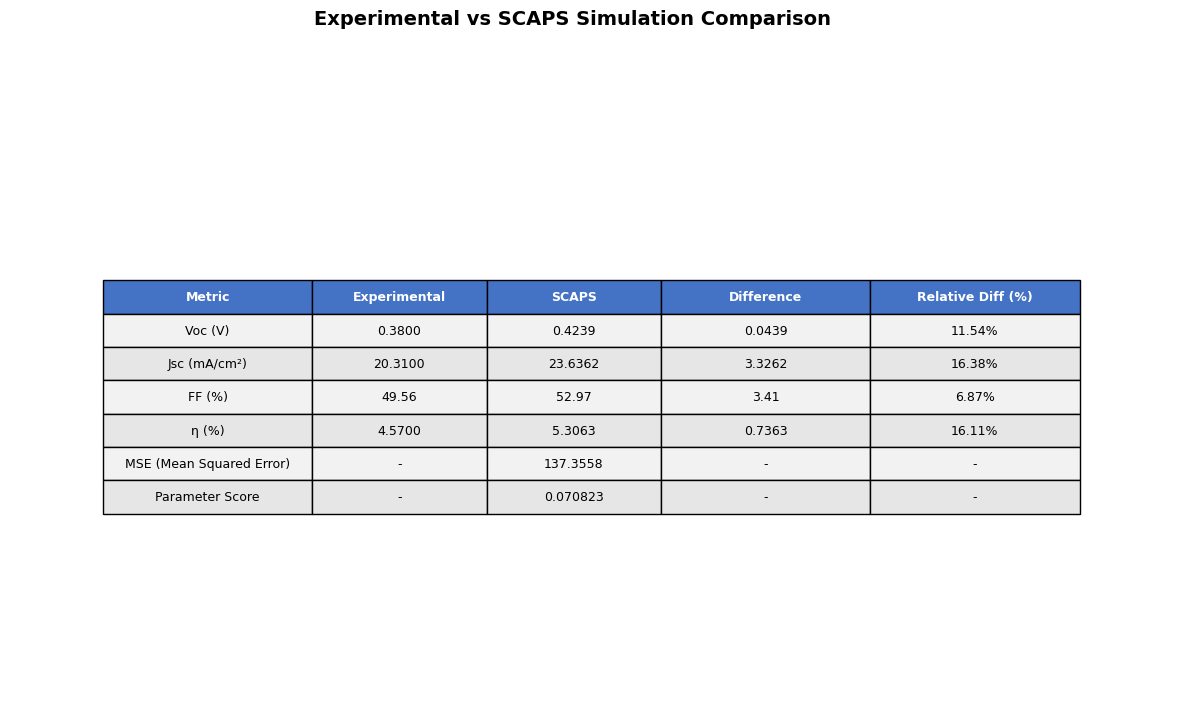

✅ Saved Comparison Table to Plots/Comparison_Table.png


In [34]:
# Calculate MSE for comparison (without creating plots)
for d in scaps_data:
    v_sim = d['v(V)']
    j_sim = d['jtot(mA/cm2)']
    
    # Ensure arrays are proper numpy arrays
    v_sim = np.asarray(v_sim, dtype=float)
    j_sim = np.asarray(j_sim, dtype=float)
    
    # Remove any NaN values
    valid_mask = np.isfinite(v_sim) & np.isfinite(j_sim)
    v_sim_clean = v_sim[valid_mask]
    j_sim_clean = j_sim[valid_mask]
    
    if len(v_sim_clean) < 2:
        d['mse'] = np.nan
        continue
    
    try:
        # Create interpolator
        interp_func = interp1d(v_sim_clean, j_sim_clean, kind='linear', fill_value="extrapolate")
        
        # Overlapping region
        v_min = max(v_sim_clean.min(), exp_data['v(V)'].min())
        v_max = min(v_sim_clean.max(), exp_data['v(V)'].max())
        
        valid_exp = exp_data[(exp_data['v(V)'] >= v_min) & (exp_data['v(V)'] <= v_max)]
        
        if len(valid_exp) > 2:
            j_sim_interp = interp_func(valid_exp['v(V)'].values)
            j_sim_interp = np.nan_to_num(j_sim_interp, nan=0.0, posinf=100.0, neginf=-100.0)
            j_exp_vals = valid_exp['jtot(mA/cm2)'].values
            mse = mean_squared_error(j_exp_vals, j_sim_interp)
            d['mse'] = mse
        else:
            d['mse'] = np.nan
    except Exception as e:
        d['mse'] = np.nan

# Calculate parameter scores
for d in scaps_data:
    score = 0
    score += ((d['Voc'] - TARGET_VOC) / TARGET_VOC)**2
    score += ((d['Jsc'] - TARGET_JSC) / TARGET_JSC)**2
    score += ((d['FF'] - TARGET_FF) / TARGET_FF)**2
    score += ((d['eta'] - TARGET_ETA) / TARGET_ETA)**2
    d['param_score'] = score

# ==================== PLOT 3: OVERLAY WITH J LIMITATION ON SCAPS ====================
fig3_overlay = go.Figure()

# Add experimental data (no filtering)
fig3_overlay.add_trace(go.Scatter(
    x=exp_data['v(V)'], 
    y=exp_data['jtot(mA/cm2)'], 
    mode='lines', 
    name='Experimental Data', 
    line=dict(color='black', width=3, dash='dash'),
    hovertemplate='<b>Experimental</b><br>V: %{x:.3f} V<br>J: %{y:.2f} mA/cm²<extra></extra>'
))

# Add SCAPS simulations (filtered by J_MAX only)
import plotly.express as px
color_palette = px.colors.qualitative.Plotly

for i, d in enumerate(scaps_data):
    # NO FILTERING - show all SCAPS data points
    
    # Hover information
    hover_text = f"<b>{d['label']}</b><br>Voc: {d['Voc']:.4f} V<br>Jsc: {d['Jsc']:.4f} mA/cm²<br>FF: {d['FF']:.2f} %<br>η: {d['eta']:.2f} %"
    
    legend_name = f"SCAPS Simulation" if len(scaps_data) == 1 else f"Sim {i+1}"
    line_color = color_palette[i % len(color_palette)] if len(scaps_data) > 1 else '#ff7f0e'
    
    fig3_overlay.add_trace(go.Scatter(
        x=d['v(V)'], 
        y=d['jtot(mA/cm2)'], 
        mode='lines', 
        name=legend_name,
        line=dict(color=line_color, width=2.5),
        hovertemplate=hover_text + '<extra></extra>'
    ))

fig3_overlay.update_xaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig3_overlay.update_yaxes(showline=True, linewidth=2, linecolor='black', mirror=True)
fig3_overlay.update_layout(
    title='Experimental vs SCAPS (All Data Points)',
    xaxis_title='Voltage (V)',
    yaxis_title='Current Density (mA/cm²)',
    hovermode='closest',
    template='plotly_white',
    width=1000,
    height=650,
    plot_bgcolor='white',
    xaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
    yaxis=dict(showgrid=True, gridwidth=1, gridcolor='lightgray'),
)
fig3_overlay.show()
fig3_overlay.write_image(os.path.join(plots_dir, 'Experimental_vs_SCAPS_Limited.png'), width=1000, height=650)

print(f"✅ Saved Plot 3 to {plots_dir}/Experimental_vs_SCAPS_Limited.png")

# ==================== COMPARISON TABLE ====================
# Prepare table data
exp_voc = TARGET_VOC
exp_jsc = TARGET_JSC
exp_ff = TARGET_FF
exp_eta = TARGET_ETA

table_data = []
for i, d in enumerate(scaps_data):
    mse_val = d['mse'] if not np.isnan(d['mse']) else "N/A"
    mse_str = f"{mse_val:.4f}" if isinstance(mse_val, float) else mse_val
    
    table_data.append({
        'Metric': 'Voc (V)',
        'Experimental': f"{exp_voc:.4f}",
        'SCAPS': f"{d['Voc']:.4f}",
        'Difference': f"{abs(d['Voc'] - exp_voc):.4f}",
        'Relative Diff (%)': f"{abs(d['Voc'] - exp_voc) / exp_voc * 100:.2f}%"
    })
    
    table_data.append({
        'Metric': 'Jsc (mA/cm²)',
        'Experimental': f"{exp_jsc:.4f}",
        'SCAPS': f"{d['Jsc']:.4f}",
        'Difference': f"{abs(d['Jsc'] - exp_jsc):.4f}",
        'Relative Diff (%)': f"{abs(d['Jsc'] - exp_jsc) / exp_jsc * 100:.2f}%"
    })
    
    table_data.append({
        'Metric': 'FF (%)',
        'Experimental': f"{exp_ff:.2f}",
        'SCAPS': f"{d['FF']:.2f}",
        'Difference': f"{abs(d['FF'] - exp_ff):.2f}",
        'Relative Diff (%)': f"{abs(d['FF'] - exp_ff) / exp_ff * 100:.2f}%"
    })
    
    table_data.append({
        'Metric': 'η (%)',
        'Experimental': f"{exp_eta:.4f}",
        'SCAPS': f"{d['eta']:.4f}",
        'Difference': f"{abs(d['eta'] - exp_eta):.4f}",
        'Relative Diff (%)': f"{abs(d['eta'] - exp_eta) / exp_eta * 100:.2f}%"
    })
    
    table_data.append({
        'Metric': 'MSE (Mean Squared Error)',
        'Experimental': '-',
        'SCAPS': mse_str,
        'Difference': '-',
        'Relative Diff (%)': '-'
    })
    
    table_data.append({
        'Metric': 'Parameter Score',
        'Experimental': '-',
        'SCAPS': f"{d['param_score']:.6f}",
        'Difference': '-',
        'Relative Diff (%)': '-'
    })

comparison_df = pd.DataFrame(table_data)

# Save comparison table as image
fig_comp_table, ax = plt.subplots(figsize=(15, 8))
ax.axis('tight')
ax.axis('off')

# Create table
table = ax.table(cellText=comparison_df.values, 
                colLabels=comparison_df.columns,
                cellLoc='center', 
                loc='center',
                colWidths=[0.18, 0.15, 0.15, 0.18, 0.18])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 2)

# Style header
for i in range(len(comparison_df.columns)):
    cell = table[(0, i)]
    cell.set_facecolor('#4472C4')
    cell.set_text_props(weight='bold', color='white')

# Style alternating rows with light colors
for i in range(1, len(comparison_df) + 1):
    for j in range(len(comparison_df.columns)):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#E7E6E6')
        else:
            cell.set_facecolor('#F2F2F2')

fig_comp_table.suptitle('Experimental vs SCAPS Simulation Comparison', fontsize=14, fontweight='bold', y=0.98)

comp_table_path = os.path.join(plots_dir, 'Comparison_Table.png')
plt.savefig(comp_table_path, dpi=300, bbox_inches='tight')
plt.show()
plt.close()
print(f"✅ Saved Comparison Table to {plots_dir}/Comparison_Table.png")
